# 19 — T cells point their ribosome-rich cytoplasm at vessels: seeing is believing

Notebooks 06, 07 and 13: in T cells near a vessel, the 18S rRNA signal (ribosome-rich cytoplasm) sits off-centre,
towards the nearest vessel cell (median cos 0.14 in runs 5/6, 0.19 in runs 1–3); neurons show nothing. Here, all five
runs, with the controls that matter and the tissue itself:

1. **Who does it?** CD4 vs CD8 T cells, B cells, macrophages, microglia, DC, neutrophils, fibroblasts; neurons and
   oligodendrocytes as negative controls.
2. **Is it optical bleed?** If 18S from a bright neighbour spilled into the T-cell outline, T cells would point at *any*
   close neighbour. Test: orientation towards the nearest vessel cell vs towards a non-vessel neighbour at the same
   distance; and DAPI "polarity" (nucleus, should not point at vessels).
3. **Distance, lesion, stage**: does it fade with distance from the vessel; is it stronger in lesions or at peak?
4. **Vessel or antigen-presenting cell?** T cells polarise towards cells presenting antigen. Where the nearest vessel
   and the nearest MHC-II-high myeloid cell lie in different directions, which one do T cells face?
5. **The tissue**: a random gallery with arrows; a perivascular cuff with every T cell's direction drawn on the 18S
   image; polar histograms.

Polarity (notebook 01): offset of the 18S intensity-weighted centroid from the cell's geometric centroid (intensity
above the cell's 10th percentile), in µm; its direction is compared with the direction to a target cell by the cosine
(+1 = pointing straight at it, 0 = sideways, −1 = away). Unit = animal (mean cos per animal, ≥ 20 cells; Wilcoxon vs 0).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import wilcoxon
from skimage.segmentation import find_boundaries

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/19_tcell_polarity.ipynb"
OUT = ROOT / "results" / "19_tcell_polarity"
OUT.mkdir(parents=True, exist_ok=True)
COL = plotting.CATEGORICAL
PX = 0.2125
NEAR = 15.0  # µm: "perivascular"

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "Anno_L1_curated", "Anno_L2",
             "x_centroid", "y_centroid"]].copy()
mhc = [g for g in ["H2-Aa", "H2-Ab1", "H2-Eb1", "Cd74"] if g in set(a.var_names)]
my = obs.index[obs.Anno_L1_curated.isin(["Myeloid", "DC"])]
Xm = a[my.to_numpy(), mhc].to_memory().X
Xm = Xm.toarray() if hasattr(Xm, "toarray") else np.asarray(Xm)
a.file.close()
obs["stage"] = obs.stage.astype(str)
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet")[["lesion_state", "ctype"]])
obs["mhc2"] = np.nan
obs.loc[my, "mhc2"] = Xm.mean(1)
apc = obs.mhc2 > obs.loc[my, "mhc2"].quantile(0.75)          # MHC-II-high macrophages / microglia / DC
vessel = obs.Anno_L1_curated.isin(["Endothelial", "VSMC"])
GROUP = {"PEAK1": "peak", "PEAK2": "peak", "PEAK2_MILD": "peak", "PEAK3": "peak", "OS1": "onset", "ONSET1": "onset",
         "ONSET2": "onset", "MILD16": "chronic late", "SEVERE16": "chronic late", "MILD30": "chronic late",
         "SEVERE30": "chronic late", "REMISSION1": "recovery", "REMISSION2": "recovery", "REMISSION2_LONG": "recovery",
         "MONOPHASIC": "recovery"}
obs["group"] = obs.stage.map(GROUP).fillna("control")

COLS = ["section_id", "segmentation_method", "centroid_x_px", "centroid_y_px", "label",
        "r18s_polarity_dx_um", "r18s_polarity_dy_um", "r18s_polarity_shape",
        "dapi_polarity_dx_um", "dapi_polarity_dy_um", "smavim_polarity_dx_um", "smavim_polarity_dy_um"]
fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=COLS)
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"].join(obs, how="inner")
print(len(fa), "18S-segmented annotated cells")

1323517 18S-segmented annotated cells


In [3]:
def unit(dx, dy):
    n = np.hypot(dx, dy)
    return dx / n, dy / n


def cosine(ax_, ay_, bx, by):
    return (ax_ * bx + ay_ * by) / (np.hypot(ax_, ay_) * np.hypot(bx, by))


# nearest vessel cell, nearest MHC-II-high APC, nearest cell of any kind, and a non-vessel neighbour at the
# same distance as the nearest vessel cell (bleed control); all within the same tissue piece, self excluded
for c in ["v_d", "v_dx", "v_dy", "a_d", "a_dx", "a_dy", "n_d", "n_dx", "n_dy", "m_dx", "m_dy", "m_d", "other_piece"]:
    fa[c] = np.nan
for pc, g in obs.groupby("meta_sample_id", observed=True):
    f = fa.index.intersection(g.index)
    if len(f) == 0:
        continue
    xy_all = g[["x_centroid", "y_centroid"]].to_numpy()
    xy = fa.loc[f, ["x_centroid", "y_centroid"]].to_numpy()
    t_all = cKDTree(xy_all)
    dk, jk = t_all.query(xy, k=25)
    is_ves = vessel.reindex(g.index).to_numpy()
    for name, mask in [("v", is_ves), ("a", apc.reindex(g.index).fillna(False).to_numpy())]:
        if mask.sum() < 2:
            continue
        tt = cKDTree(xy_all[mask])
        d, j = tt.query(xy, k=2)
        tgt = xy_all[mask]
        self_ = d[:, 0] < 1e-6
        jj = np.where(self_, j[:, 1], j[:, 0]); dd = np.where(self_, d[:, 1], d[:, 0])
        fa.loc[f, f"{name}_d"] = dd
        fa.loc[f, f"{name}_dx"] = tgt[jj, 0] - xy[:, 0]
        fa.loc[f, f"{name}_dy"] = tgt[jj, 1] - xy[:, 1]
    # nearest other cell (any type)
    fa.loc[f, "n_d"] = dk[:, 1]
    fa.loc[f, "n_dx"] = xy_all[jk[:, 1], 0] - xy[:, 0]
    fa.loc[f, "n_dy"] = xy_all[jk[:, 1], 1] - xy[:, 1]
    # matched-distance non-vessel neighbour
    vd = fa.loc[f, "v_d"].to_numpy()
    nonv = ~is_ves[jk[:, 1:]]
    gap = np.abs(dk[:, 1:] - vd[:, None])
    gap = np.where(nonv, gap, np.inf)
    best = np.argmin(gap, axis=1)
    okm = np.isfinite(gap[np.arange(len(best)), best]) & (gap[np.arange(len(best)), best] <= 3)
    jb = jk[np.arange(len(best)), best + 1]
    fa.loc[f, "m_dx"] = np.where(okm, xy_all[jb, 0] - xy[:, 0], np.nan)
    fa.loc[f, "m_dy"] = np.where(okm, xy_all[jb, 1] - xy[:, 1], np.nan)
    fa.loc[f, "m_d"] = np.where(okm, dk[np.arange(len(best)), best + 1], np.nan)
# cells < 20 µm from another tissue piece: no polarity readout (pieces touch in runs 1-3)
for _, g in obs.groupby("sample_id", observed=True):
    xy, pcs = g[["x_centroid", "y_centroid"]].to_numpy(), g.meta_sample_id.astype(str).to_numpy()
    for p in np.unique(pcs):
        m = pcs == p
        if not m.all():
            idx = fa.index.intersection(g.index[m])
            if len(idx):
                fa.loc[idx, "other_piece"] = cKDTree(xy[~m]).query(fa.loc[idx, ["x_centroid", "y_centroid"]].to_numpy())[0]
fa = fa[~(fa.other_piece < 20)]
fa["cos_vessel"] = cosine(fa.r18s_polarity_dx_um, fa.r18s_polarity_dy_um, fa.v_dx, fa.v_dy)
fa["cos_matched"] = cosine(fa.r18s_polarity_dx_um, fa.r18s_polarity_dy_um, fa.m_dx, fa.m_dy)
fa["cos_nearest"] = cosine(fa.r18s_polarity_dx_um, fa.r18s_polarity_dy_um, fa.n_dx, fa.n_dy)
fa["cos_apc"] = cosine(fa.r18s_polarity_dx_um, fa.r18s_polarity_dy_um, fa.a_dx, fa.a_dy)
fa["cos_vessel_dapi"] = cosine(fa.dapi_polarity_dx_um, fa.dapi_polarity_dy_um, fa.v_dx, fa.v_dy)
fa["cos_vessel_smavim"] = cosine(fa.smavim_polarity_dx_um, fa.smavim_polarity_dy_um, fa.v_dx, fa.v_dy)
print(fa[["cos_vessel", "cos_matched", "cos_apc"]].notna().sum().to_dict())

{'cos_vessel': 1323372, 'cos_matched': 834200, 'cos_apc': 1323372}


## 1. Who points at vessels?

In [4]:
CELLS = {
    "T cell (all)": fa.ctype == "T cell", "CD4 T": fa.Anno_L2 == "CD4+ T Cell", "CD8 T": fa.Anno_L2 == "CD8+ T Cell",
    "B cell": fa.ctype == "B cell", "MDM": fa.Anno_L2 == "MDM", "Microglia": fa.Anno_L2 == "Microglia",
    "DC": fa.Anno_L1_curated == "DC", "NK/DC": fa.Anno_L1_curated == "NK/DC", "Neutrophil": fa.Anno_L1_curated == "Neutrophil",
    "Fibroblast": fa.Anno_L1_curated == "Fibroblast", "Astrocyte": fa.Anno_L1_curated == "Astrocyte",
    "Neuron (control)": fa.Anno_L1_curated == "Neuron", "Oligodendrocyte (control)": fa.Anno_L1_curated == "Oligodendrocyte",
}


def per_animal(cells, col, min_n=20):
    g = cells.groupby("sample_name", observed=True)[col].agg(["mean", "size"])
    return g[g["size"] >= min_n]["mean"]


def summarise(v):
    v = v.dropna()
    return dict(animals=len(v), median_cos=v.median(), share_positive=(v > 0).mean(),
                p=wilcoxon(v).pvalue if len(v) >= 6 else np.nan)


peri = (fa.v_d > 0) & (fa.v_d < NEAR)
rows = []
for name, m in CELLS.items():
    d = fa[m & peri]
    rows.append(dict(cells=name, n_cells=len(d), **summarise(per_animal(d, "cos_vessel"))))
who = pd.DataFrame(rows).set_index("cells")
who.to_csv(OUT / "who_points_at_vessels.csv")
who.round(3)

,n_cells,animals,median_cos,share_positive,p
cells,,,,,
T cell (all),12378,54,0.172,0.981,0.000
CD4 T,10056,53,0.171,0.981,0.000
CD8 T,450,3,0.070,0.667,NaN
B cell,4682,36,0.133,0.917,0.000
MDM,7417,38,0.111,0.974,0.000
Microglia,16323,67,0.066,0.881,0.000
DC,11270,51,0.154,0.941,0.000
NK/DC,2608,34,0.151,0.941,0.000
Neutrophil,37,0,NaN,NaN,NaN


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/19_tcell_polarity/who_points_at_vessels.png')

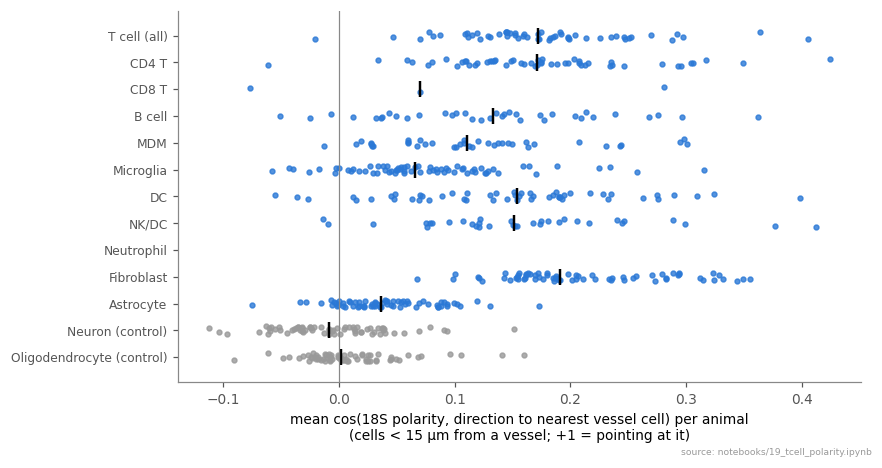

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (name, m) in enumerate(CELLS.items()):
    v = per_animal(fa[m & peri], "cos_vessel").dropna()
    ax.scatter(v, np.full(len(v), i) + np.random.default_rng(i).uniform(-0.15, 0.15, len(v)), s=10,
               color=COL[0] if "control" not in name else "#999999", alpha=0.8)
    ax.vlines(v.median(), i - 0.3, i + 0.3, color="black", lw=1.6)
ax.axvline(0, color="#888888", lw=0.8)
ax.set_yticks(range(len(CELLS)), list(CELLS), fontsize=8); ax.invert_yaxis()
ax.set_xlabel("mean cos(18S polarity, direction to nearest vessel cell) per animal\n(cells < 15 µm from a vessel; +1 = pointing at it)")
fig.tight_layout()
plotting.save_fig(fig, "who_points_at_vessels", OUT, SRC)

## 2. Is it optical bleed?
For the same perivascular cells: orientation towards (a) the nearest vessel cell, (b) a non-vessel neighbour at the
same distance (± 3 µm), (c) the nearest cell of any type; and the DAPI and αSMA/Vim "polarity" towards the vessel.
Bleed would make (b) and (c) as strong as (a), and the DAPI/αSMA polarity would point at vessels too.

In [6]:
rows = []
for name in ["T cell (all)", "CD4 T", "CD8 T", "MDM", "Fibroblast", "Neuron (control)", "Oligodendrocyte (control)"]:
    d = fa[CELLS[name] & peri]
    for lab, col in [("18S → nearest vessel cell", "cos_vessel"), ("18S → non-vessel neighbour, same distance", "cos_matched"),
                     ("18S → nearest cell (any)", "cos_nearest"), ("DAPI → vessel", "cos_vessel_dapi"),
                     ("αSMA/Vim → vessel", "cos_vessel_smavim")]:
        rows.append(dict(cells=name, comparison=lab, **summarise(per_animal(d, col))))
bleed = pd.DataFrame(rows)
bleed.to_csv(OUT / "bleed_controls.csv", index=False)
bleed.pivot(index="cells", columns="comparison", values="median_cos").round(3)

comparison,18S → nearest cell (any),18S → nearest vessel cell,"18S → non-vessel neighbour, same distance",DAPI → vessel,αSMA/Vim → vessel
cells,,,,,
CD4 T,0.090,0.171,0.045,0.146,0.012
CD8 T,0.029,0.070,-0.080,0.115,-0.038
Fibroblast,0.136,0.191,0.049,0.151,0.062
MDM,0.099,0.111,0.047,0.133,0.045
Neuron (control),0.050,-0.008,0.023,0.064,0.114
Oligodendrocyte (control),0.094,0.001,0.093,0.095,0.160
T cell (all),0.097,0.172,0.047,0.138,0.024


T cells: vessel − matched neighbour, per animal: median +0.121, 94% of 54 animals > 0, Wilcoxon p = 9e-10


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/19_tcell_polarity/vessel_vs_matched_neighbour.png')

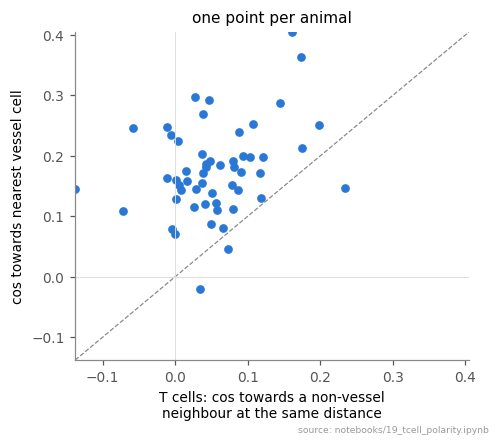

In [7]:
d = fa[CELLS["T cell (all)"] & peri]
pv = pd.DataFrame({"towards vessel": per_animal(d, "cos_vessel"), "towards matched neighbour": per_animal(d, "cos_matched")}).dropna()
diff = pv["towards vessel"] - pv["towards matched neighbour"]
print(f"T cells: vessel − matched neighbour, per animal: median {diff.median():+.3f}, "
      f"{(diff > 0).mean():.0%} of {len(diff)} animals > 0, Wilcoxon p = {wilcoxon(diff).pvalue:.2g}")
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(pv["towards matched neighbour"], pv["towards vessel"], s=22, color=COL[0])
lim = [min(pv.min().min(), -0.05), max(pv.max().max(), 0.4)]
ax.plot(lim, lim, color="#888888", lw=0.8, ls="--")
ax.axhline(0, color="#dddddd", lw=0.6); ax.axvline(0, color="#dddddd", lw=0.6)
ax.set(xlabel="T cells: cos towards a non-vessel\nneighbour at the same distance", ylabel="cos towards nearest vessel cell",
       title="one point per animal", xlim=lim, ylim=lim)
fig.tight_layout()
plotting.save_fig(fig, "vessel_vs_matched_neighbour", OUT, SRC)

### 2b. Outline-shape artefact? 18S relative to the cell's own nucleus
DAPI "polarity" of T cells also points at vessels. A geometric explanation: a T cell squeezed against a vessel may get
an outline that extends mostly away from the vessel, shifting the outline's centre away, so anything inside (nucleus
included) looks shifted towards the vessel. Test that is independent of the outline: the vector from the DAPI
(nucleus) intensity centroid to the 18S intensity centroid, i.e. which side of its own nucleus the ribosome-rich
cytoplasm sits on. Its cosine with the vessel direction should stay positive if the orientation is real.

In [8]:
fa["nuc2r_dx"] = fa.r18s_polarity_dx_um - fa.dapi_polarity_dx_um
fa["nuc2r_dy"] = fa.r18s_polarity_dy_um - fa.dapi_polarity_dy_um
fa["cos_vessel_rel_nuc"] = cosine(fa.nuc2r_dx, fa.nuc2r_dy, fa.v_dx, fa.v_dy)
fa["cos_matched_rel_nuc"] = cosine(fa.nuc2r_dx, fa.nuc2r_dy, fa.m_dx, fa.m_dy)
rows = []
for name in ["T cell (all)", "CD4 T", "B cell", "DC", "MDM", "Microglia", "Fibroblast", "Neuron (control)",
             "Oligodendrocyte (control)"]:
    d = fa[CELLS[name] & peri]
    for lab, col in [("vs outline centre (original)", "cos_vessel"), ("relative to own nucleus", "cos_vessel_rel_nuc"),
                     ("relative to own nucleus → matched non-vessel neighbour", "cos_matched_rel_nuc")]:
        rows.append(dict(cells=name, measure=lab, **summarise(per_animal(d, col))))
relnuc = pd.DataFrame(rows)
relnuc.to_csv(OUT / "relative_to_nucleus.csv", index=False)
relnuc.pivot(index="cells", columns="measure", values="median_cos").round(3)

measure,relative to own nucleus,relative to own nucleus → matched non-vessel neighbour,vs outline centre (original)
cells,,,
B cell,0.083,-0.041,0.133
CD4 T,0.042,-0.032,0.171
DC,0.028,-0.030,0.154
Fibroblast,0.054,-0.037,0.191
MDM,0.022,-0.034,0.111
Microglia,-0.000,-0.014,0.066
Neuron (control),-0.043,-0.090,-0.008
Oligodendrocyte (control),-0.047,-0.009,0.001
T cell (all),0.047,-0.032,0.172


In [9]:
relnuc.pivot(index="cells", columns="measure", values="p").map(lambda v: f"{v:.1g}")

measure,relative to own nucleus,relative to own nucleus → matched non-vessel neighbour,vs outline centre (original)
cells,,,
B cell,0.003,0.0005,3e-09
CD4 T,2e-05,0.005,3e-10
DC,0.004,0.0006,1e-09
Fibroblast,3e-09,3e-07,1e-12
MDM,0.03,0.04,1e-11
Microglia,1,0.006,5e-11
Neuron (control),8e-10,4e-12,0.2
Oligodendrocyte (control),1e-09,0.03,0.2
T cell (all),9e-07,0.001,2e-10


### 2c. Bright-neighbour bleed? A brightness-matched control
In the gallery several arrows point into an 18S-bright neighbour touching the T cell. Blur from a bright neighbour
spills into the edge of the outline and pulls the intensity centroid towards it. Vessel cells may simply be brighter
in 18S than the average neighbour, so the same-distance control above is not enough. Decisive control: a non-vessel
neighbour at the same distance (± 3 µm) that is **at least as bright in 18S** (raw cell mean) as the nearest vessel
cell. If cells point at it as much as at the vessel, the effect is brightness bleed.

In [10]:
br = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=["r18s_cell_mean", "r18s_scale", "r18s_bg_local"])
raw18 = (br.r18s_cell_mean * br.r18s_scale + br.r18s_bg_local).reindex(obs.index)
fa["b_dx"] = np.nan; fa["b_dy"] = np.nan; fa["v_bright"] = np.nan
for pc, g in obs.groupby("meta_sample_id", observed=True):
    f = fa.index.intersection(g.index)
    if len(f) == 0:
        continue
    xy_all = g[["x_centroid", "y_centroid"]].to_numpy()
    xy = fa.loc[f, ["x_centroid", "y_centroid"]].to_numpy()
    bright = raw18.reindex(g.index).to_numpy()
    is_ves = vessel.reindex(g.index).to_numpy()
    if is_ves.sum() < 2:
        continue
    dk, jk = cKDTree(xy_all).query(xy, k=30)
    vtree = cKDTree(xy_all[is_ves]); vidx = np.flatnonzero(is_ves)
    dv, jv = vtree.query(xy, k=2)
    self_ = dv[:, 0] < 1e-6
    jvn = vidx[np.where(self_, jv[:, 1], jv[:, 0])]; dvn = np.where(self_, dv[:, 1], dv[:, 0])
    vb = bright[jvn]
    cand_ok = (~is_ves[jk[:, 1:]]) & (np.abs(dk[:, 1:] - dvn[:, None]) <= 3) & (bright[jk[:, 1:]] >= vb[:, None])
    gap = np.where(cand_ok, np.abs(dk[:, 1:] - dvn[:, None]), np.inf)
    best = np.argmin(gap, axis=1)
    okb = np.isfinite(gap[np.arange(len(best)), best])
    jb = jk[np.arange(len(best)), best + 1]
    fa.loc[f, "b_dx"] = np.where(okb, xy_all[jb, 0] - xy[:, 0], np.nan)
    fa.loc[f, "b_dy"] = np.where(okb, xy_all[jb, 1] - xy[:, 1], np.nan)
    fa.loc[f, "v_bright"] = vb
fa["cos_bright"] = cosine(fa.r18s_polarity_dx_um, fa.r18s_polarity_dy_um, fa.b_dx, fa.b_dy)
fa["cos_bright_rel_nuc"] = cosine(fa.nuc2r_dx, fa.nuc2r_dy, fa.b_dx, fa.b_dy)
rows = []
for name in ["T cell (all)", "CD4 T", "B cell", "Fibroblast", "Neuron (control)", "Oligodendrocyte (control)"]:
    d = fa[CELLS[name] & peri & fa.cos_bright.notna()]
    for lab, col in [("vessel (outline)", "cos_vessel"), ("bright non-vessel neighbour (outline)", "cos_bright"),
                     ("vessel (rel. nucleus)", "cos_vessel_rel_nuc"),
                     ("bright non-vessel neighbour (rel. nucleus)", "cos_bright_rel_nuc")]:
        rows.append(dict(cells=name, target=lab, n_cells=len(d), **summarise(per_animal(d, col, 10))))
brt = pd.DataFrame(rows)
brt.to_csv(OUT / "brightness_matched_control.csv", index=False)
brt.pivot(index="cells", columns="target", values="median_cos").round(3)

target,bright non-vessel neighbour (outline),bright non-vessel neighbour (rel. nucleus),vessel (outline),vessel (rel. nucleus)
cells,,,,
B cell,0.169,0.006,0.047,0.044
CD4 T,0.193,0.037,0.095,0.021
Fibroblast,0.194,0.053,0.093,-0.002
Neuron (control),0.038,-0.081,-0.029,-0.020
Oligodendrocyte (control),0.144,0.020,-0.051,-0.060
T cell (all),0.189,0.046,0.083,0.017


In [11]:
d = fa[CELLS["T cell (all)"] & peri & fa.cos_bright.notna()]
for kind, (cv, cb) in {"outline": ("cos_vessel", "cos_bright"), "rel. nucleus": ("cos_vessel_rel_nuc", "cos_bright_rel_nuc")}.items():
    pv = pd.DataFrame({"v": per_animal(d, cv, 10), "b": per_animal(d, cb, 10)}).dropna()
    dd = pv.v - pv.b
    print(f"T cells ({kind}): vessel − bright matched neighbour, median {dd.median():+.3f}, {(dd > 0).mean():.0%} of "
          f"{len(dd)} animals > 0, Wilcoxon p = {wilcoxon(dd).pvalue:.2g}; vessel {pv.v.median():+.3f} vs bright {pv.b.median():+.3f}")

T cells (outline): vessel − bright matched neighbour, median -0.099, 24% of 54 animals > 0, Wilcoxon p = 3.9e-05; vessel +0.083 vs bright +0.189
T cells (rel. nucleus): vessel − bright matched neighbour, median -0.040, 39% of 54 animals > 0, Wilcoxon p = 0.058; vessel +0.017 vs bright +0.046


## 3. Distance, lesion, stage

,animals,median_cos,share_positive,p
where,,,,
lesion,53,0.172,0.981,0.000
no lesion,24,0.158,0.792,0.000
stage: onset,9,0.251,1.000,0.004
stage: peak,19,0.148,1.000,0.000
stage: chronic late,13,0.152,1.000,0.000
stage: recovery,13,0.160,0.923,0.000


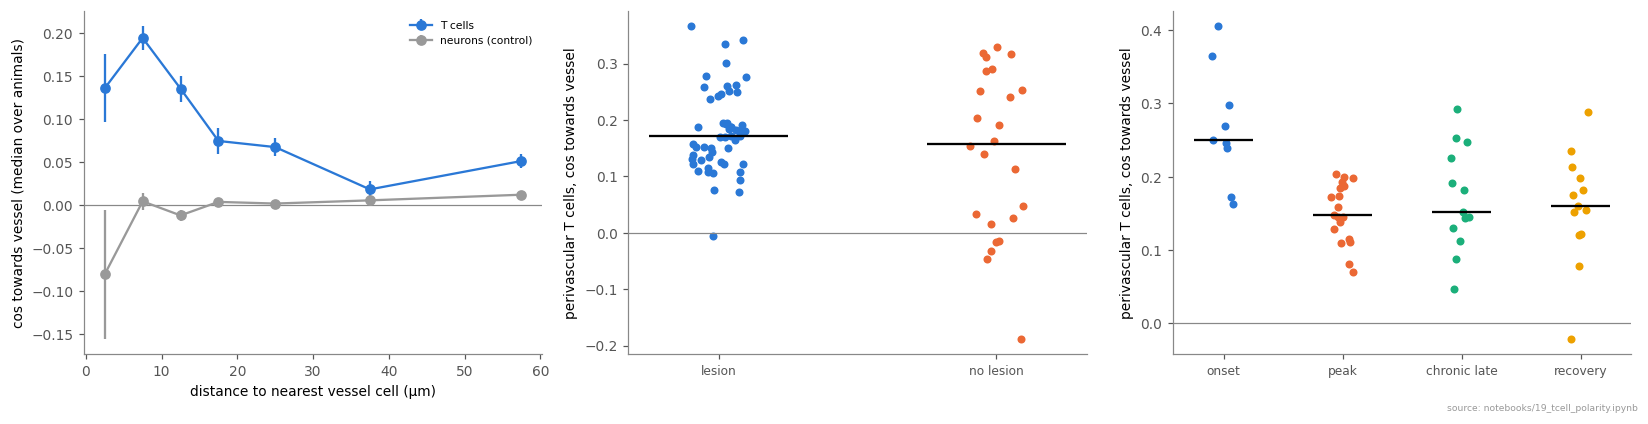

In [12]:
T = fa[CELLS["T cell (all)"] & (fa.v_d > 0)].copy()
T["dbin"] = pd.cut(T.v_d, [0, 5, 10, 15, 20, 30, 45, 70])
prof = T.groupby(["sample_name", "dbin"], observed=True).cos_vessel.agg(["mean", "size"])
prof = prof[prof["size"] >= 10]["mean"].unstack()
N_ = fa[CELLS["Neuron (control)"] & (fa.v_d > 0)].copy()
N_["dbin"] = pd.cut(N_.v_d, [0, 5, 10, 15, 20, 30, 45, 70])
profn = N_.groupby(["sample_name", "dbin"], observed=True).cos_vessel.agg(["mean", "size"])
profn = profn[profn["size"] >= 10]["mean"].unstack()
mids = [2.5, 7.5, 12.5, 17.5, 25, 37.5, 57.5]
fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
axs[0].errorbar(mids, prof.median(), prof.sem(), marker="o", color=COL[0], label="T cells")
axs[0].errorbar(mids, profn.median(), profn.sem(), marker="o", color="#999999", label="neurons (control)")
axs[0].axhline(0, color="#888888", lw=0.8)
axs[0].set(xlabel="distance to nearest vessel cell (µm)", ylabel="cos towards vessel (median over animals)")
axs[0].legend(fontsize=7)
rows = []
for lab, m in [("lesion", T.lesion_state.str.startswith("S")), ("no lesion", T.lesion_state == "no lesion")]:
    rows.append(dict(where=lab, **summarise(per_animal(T[m & (T.v_d < NEAR)], "cos_vessel"))))
for grp in ["onset", "peak", "chronic late", "recovery"]:
    rows.append(dict(where=f"stage: {grp}", **summarise(per_animal(T[(T.group == grp) & (T.v_d < NEAR)], "cos_vessel"))))
ctx = pd.DataFrame(rows).set_index("where")
ctx.to_csv(OUT / "context.csv")
for ax, sel in zip(axs[1:], [["lesion", "no lesion"], [f"stage: {g}" for g in ["onset", "peak", "chronic late", "recovery"]]]):
    for i, w in enumerate(sel):
        m = (T.lesion_state.str.startswith("S") if w == "lesion" else T.lesion_state == "no lesion") if w in ("lesion", "no lesion") \
            else (T.group == w.split(": ")[1])
        v = per_animal(T[m & (T.v_d < NEAR)], "cos_vessel").dropna()
        ax.scatter(np.full(len(v), i) + np.random.default_rng(i).uniform(-0.1, 0.1, len(v)), v, s=18, color=COL[i])
        ax.hlines(v.median(), i - 0.25, i + 0.25, color="black", lw=1.5)
    ax.axhline(0, color="#888888", lw=0.8)
    ax.set_xticks(range(len(sel)), [s.replace("stage: ", "") for s in sel], fontsize=8)
    ax.set_ylabel("perivascular T cells, cos towards vessel")
fig.tight_layout()
plotting.save_fig(fig, "distance_lesion_stage", OUT, SRC)
ctx.round(3)

## 4. Vessel or antigen-presenting cell?
MHC-II-high myeloid cells (macrophages, microglia, DC; top quartile of *H2-Aa, H2-Ab1, H2-Eb1, Cd74*) are candidate
antigen-presenting cells (APC). For perivascular T cells that also have an APC within 15 µm: orientation towards each.
Then the informative cases, where vessel and APC lie in clearly different directions (angle > 90°).

In [13]:
both = T[(T.v_d < NEAR) & (T.a_d < NEAR)].copy()
both["angle_vessel_apc"] = np.degrees(np.arccos(np.clip(cosine(both.v_dx, both.v_dy, both.a_dx, both.a_dy), -1, 1)))
split = both[both.angle_vessel_apc > 90]
rows = [dict(subset="T cells with vessel and APC < 15 µm", target="vessel", **summarise(per_animal(both, "cos_vessel", 10))),
        dict(subset="T cells with vessel and APC < 15 µm", target="APC", **summarise(per_animal(both, "cos_apc", 10))),
        dict(subset="… and vessel/APC > 90° apart", target="vessel", **summarise(per_animal(split, "cos_vessel", 5))),
        dict(subset="… and vessel/APC > 90° apart", target="APC", **summarise(per_animal(split, "cos_apc", 5)))]
vs_apc = pd.DataFrame(rows)
vs_apc.to_csv(OUT / "vessel_vs_apc.csv", index=False)
print(f"{len(both):,} T cells with both within 15 µm; {len(split):,} with them > 90° apart")
vs_apc.round(3)

5,298 T cells with both within 15 µm; 2,740 with them > 90° apart


,subset,target,animals,median_cos,share_positive,p
0,T cells with vessel and APC < 15 µm,vessel,52,0.147,0.962,0.000
1,T cells with vessel and APC < 15 µm,APC,52,0.073,0.788,0.000
2,… and vessel/APC > 90° apart,vessel,51,0.101,0.804,0.000
3,… and vessel/APC > 90° apart,APC,51,0.013,0.529,0.626


## 5. The tissue
**Polar histograms**: the angle between each cell's 18S polarity and the direction to its nearest vessel cell
(0° = pointing at the vessel), strongly polarised perivascular cells (top quartile of polarity magnitude per type).

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/19_tcell_polarity/polar_histograms.png')

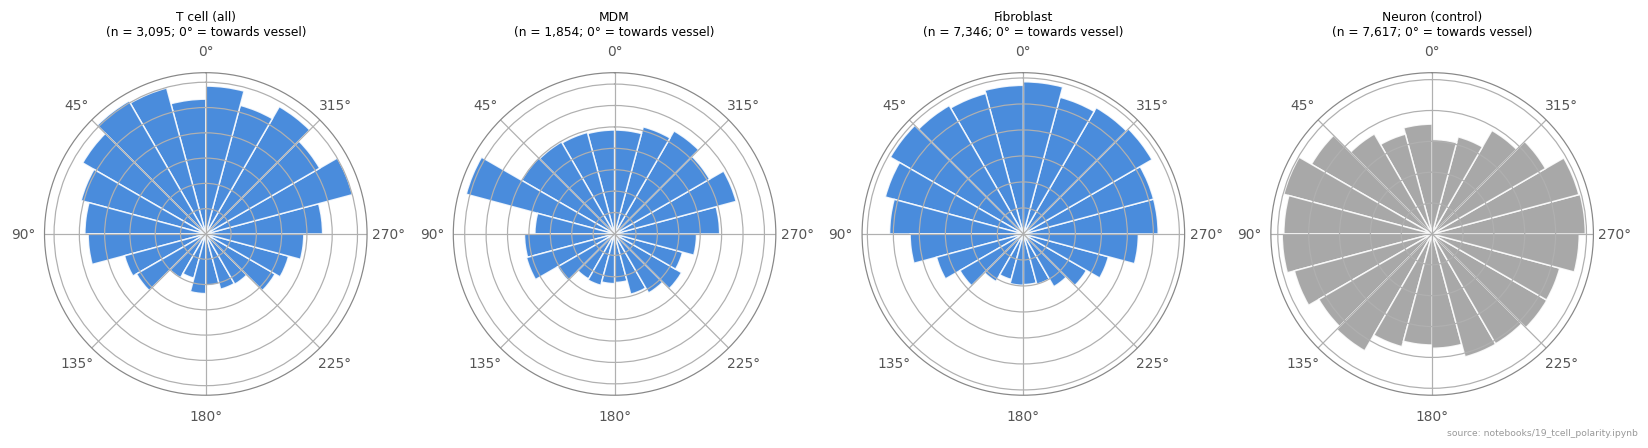

In [14]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4), subplot_kw={"projection": "polar"})
for ax, name in zip(axs, ["T cell (all)", "MDM", "Fibroblast", "Neuron (control)"]):
    d = fa[CELLS[name] & peri].dropna(subset=["cos_vessel"])
    d = d[d.r18s_polarity_shape > d.r18s_polarity_shape.quantile(0.75)]
    ang = np.arctan2(d.r18s_polarity_dy_um, d.r18s_polarity_dx_um) - np.arctan2(d.v_dy, d.v_dx)
    ang = (ang + np.pi) % (2 * np.pi) - np.pi
    h, e = np.histogram(ang, bins=24, range=(-np.pi, np.pi))
    ax.bar((e[:-1] + e[1:]) / 2, h / h.sum(), width=2 * np.pi / 24, color=COL[0] if "control" not in name else "#999999",
           alpha=0.85, edgecolor="white")
    ax.set_theta_zero_location("N"); ax.set_yticklabels([])
    ax.set_title(f"{name}\n(n = {len(d):,}; 0° = towards vessel)", fontsize=8)
fig.tight_layout()
plotting.save_fig(fig, "polar_histograms", OUT, SRC)

**Random gallery.** 18 strongly polarised perivascular T cells drawn at random (seed 0; not selected by direction).
18S channel (magma), cell outline (white), 18S polarity (yellow arrow, ×4), direction to the nearest vessel cell (cyan
arrow), vessel cells outlined in cyan.

gallery: 13 of 18 point towards the vessel half-plane


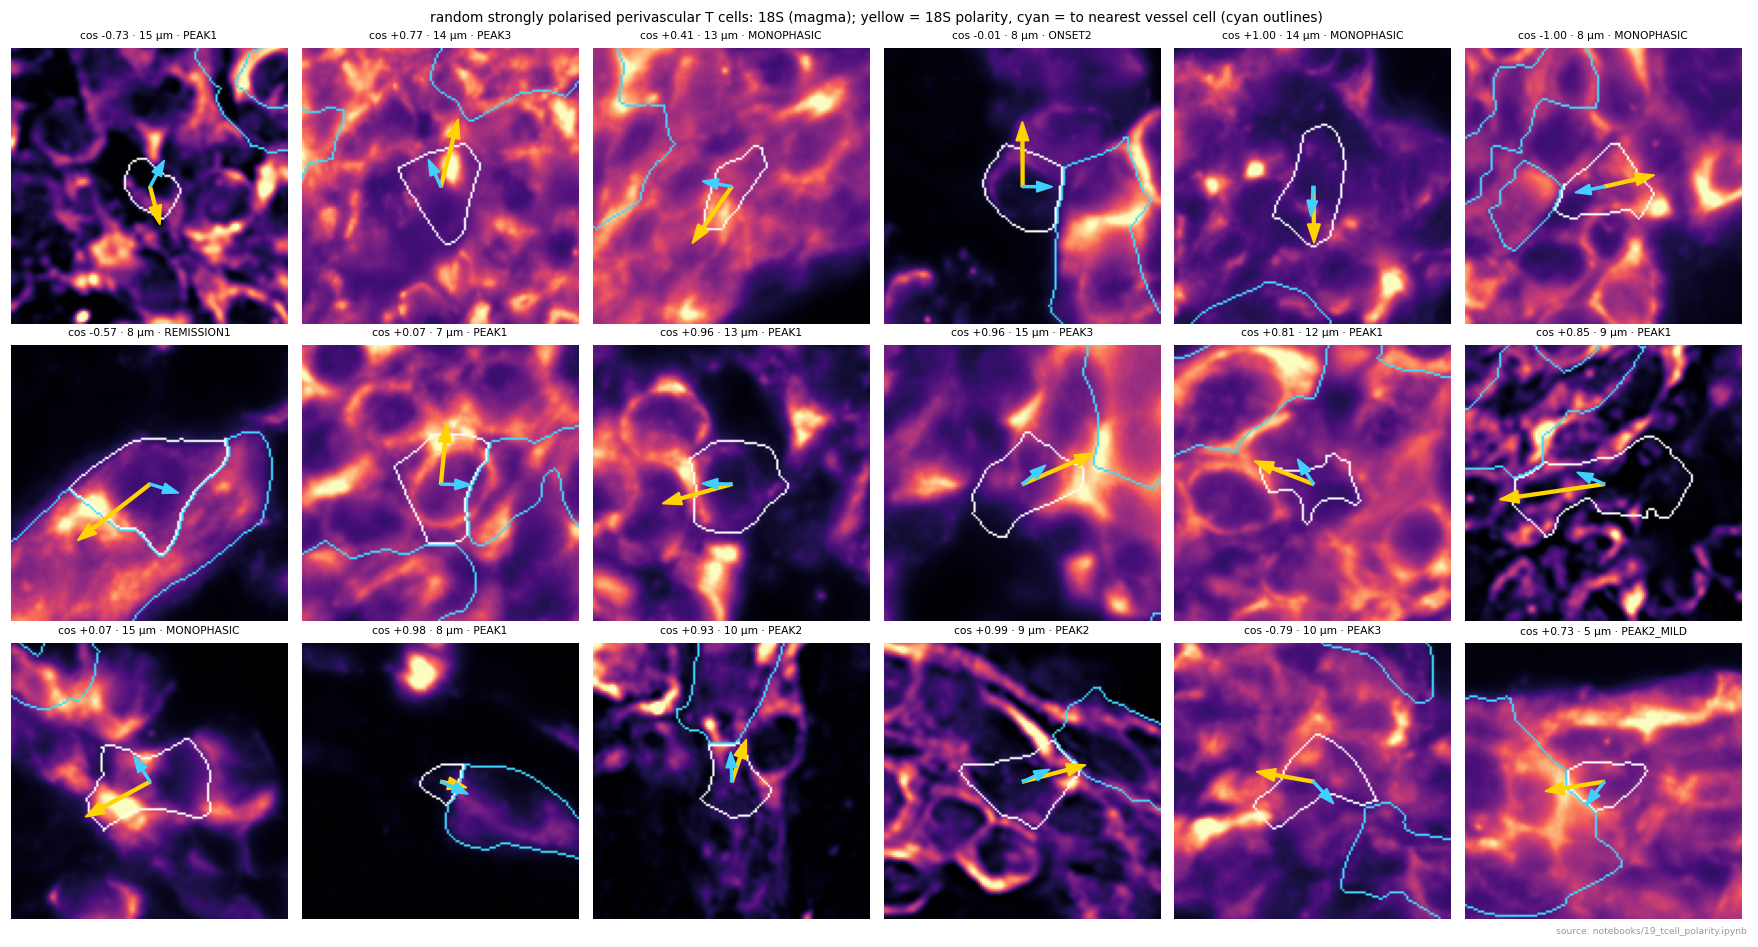

In [15]:
bundles = find_bundles(data.load_config())
_open = {}


def bundle(sec):
    if sec not in _open:
        _open[sec] = XeniumBundle(bundles[sec])
    return _open[sec]


ves_lab = fa[fa.Anno_L1_curated.isin(["Endothelial", "VSMC"])][["section_id", "label"]]
ves_by_sec = ves_lab.groupby("section_id").label.apply(lambda s: set(s.astype(int)))
Tp = fa[CELLS["T cell (all)"] & peri].dropna(subset=["cos_vessel"])
pick = Tp[Tp.r18s_polarity_shape > Tp.r18s_polarity_shape.quantile(0.75)].sample(18, random_state=0)
fig, axs = plt.subplots(3, 6, figsize=(16, 8.6))
for ax, (_, r) in zip(axs.ravel(), pick.iterrows()):
    h = int(14 / PX)
    y, x = int(r.centroid_y_px), int(r.centroid_x_px)
    img, cm, _ = bundle(r.section_id).read_window(y - h, x - h, 2 * h, 2 * h)
    im = img[2]
    rgb = plt.get_cmap("magma")(np.clip(im / np.percentile(im, 99.5), 0, 1))[..., :3]
    rgb[find_boundaries(cm == r.label, mode="inner")] = 1
    vl = ves_by_sec.get(r.section_id, set())
    if vl:
        rgb[find_boundaries(np.isin(cm, list(vl)), mode="inner")] = (0.25, 0.85, 1.0)
    ax.imshow(rgb)
    ax.arrow(h, h, r.r18s_polarity_dx_um / PX * 4, r.r18s_polarity_dy_um / PX * 4, color="#ffd400", width=1.3,
             head_width=6, length_includes_head=True)
    vx, vy = unit(r.v_dx, r.v_dy)
    ax.arrow(h, h, vx * 3 / PX, vy * 3 / PX, color="#40d0ff", width=0.9, head_width=5, length_includes_head=True)
    ax.set_title(f"cos {r.cos_vessel:+.2f} · {r.v_d:.0f} µm · {r.stage}", fontsize=7)
    ax.axis("off")
fig.suptitle("random strongly polarised perivascular T cells: 18S (magma); yellow = 18S polarity, cyan = to nearest vessel "
             "cell (cyan outlines)", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "tcell_gallery_random", OUT, SRC)
print(f"gallery: {(pick.cos_vessel > 0).sum()} of {len(pick)} point towards the vessel half-plane")

**A perivascular cuff.** The 150 µm field with the most perivascular T cells. Every T cell's 18S polarity drawn as an
arrow on the 18S image (left) and on the αSMA/vimentin image, which outlines the vessel wall (right).

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/19_tcell_polarity/perivascular_cuff_arrows.png')

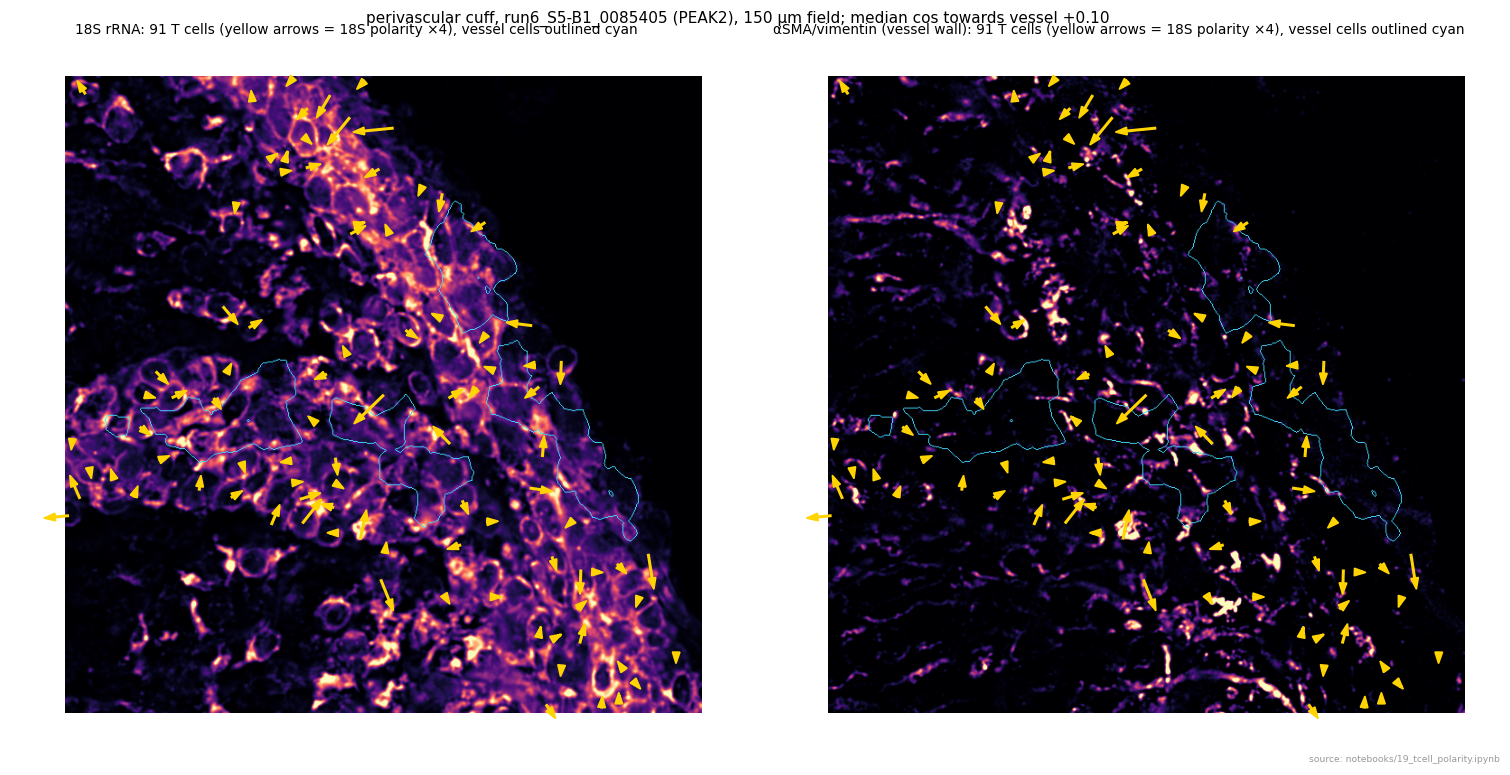

In [16]:
Tf = fa[CELLS["T cell (all)"] & peri].dropna(subset=["cos_vessel"])
best = None
for sec, g in Tf.groupby("section_id"):
    t = cKDTree(g[["x_centroid", "y_centroid"]].to_numpy())
    n = np.array([len(z) for z in t.query_ball_point(g[["x_centroid", "y_centroid"]].to_numpy(), 75)])
    if best is None or n.max() > best[0]:
        best = (n.max(), sec, g.iloc[int(n.argmax())])
_, sec, c = best
half = 75
cx, cy = c.x_centroid, c.y_centroid
y0p, x0p, hp = int((cy - half) / PX), int((cx - half) / PX), int(2 * half / PX)
img, cm, _ = bundle(sec).read_window(y0p, x0p, hp, hp)
inwin = fa[(fa.section_id == sec) & fa.x_centroid.between(cx - half, cx + half) & fa.y_centroid.between(cy - half, cy + half)]
Tw = inwin[CELLS["T cell (all)"].reindex(inwin.index) & inwin.r18s_polarity_dx_um.notna()]
Vw = inwin[inwin.Anno_L1_curated.isin(["Endothelial", "VSMC"])]
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
for ax, ch, lab in [(axs[0], 2, "18S rRNA"), (axs[1], 3, "αSMA/vimentin (vessel wall)")]:
    im = img[ch]
    rgb = plt.get_cmap("magma")(np.clip(im / np.percentile(im, 99.5), 0, 1))[..., :3]
    vb = find_boundaries(np.isin(cm, Vw.label.astype(int).to_numpy()), mode="inner")
    rgb[vb] = (0.25, 0.85, 1.0)
    ax.imshow(rgb, extent=(cx - half, cx + half, cy + half, cy - half))
    for _, r in Tw.iterrows():
        ax.arrow(r.x_centroid, r.y_centroid, r.r18s_polarity_dx_um * 4, r.r18s_polarity_dy_um * 4, color="#ffd400",
                 width=0.35, head_width=1.8, length_includes_head=True)
    ax.set_title(f"{lab}: {len(Tw)} T cells (yellow arrows = 18S polarity ×4), vessel cells outlined cyan", fontsize=9)
    ax.axis("off")
fig.suptitle(f"perivascular cuff, {sec} ({inwin.stage.iloc[0]}), 150 µm field; median cos towards vessel "
             f"{Tw.cos_vessel.median():+.2f}", fontsize=10)
fig.tight_layout()
plotting.save_fig(fig, "perivascular_cuff_arrows", OUT, SRC)

## Findings

> **Finding — the "T cells face vessels" result is an imaging artefact; withdrawn.** Measured as before (18S intensity
> centroid vs the outline centre), perivascular T cells point their 18S towards the nearest vessel cell in 98 % of 54
> animals (median cos 0.17), as do B cells, DC, macrophages and fibroblasts, and much less towards a non-vessel
> neighbour at the same distance (0.05). But two controls explain it away:
> (i) **outline geometry**: DAPI "points" at vessels as strongly (0.14), and measured relative to the cell's own nucleus
> the T-cell effect shrinks to 0.047, with negative-control cells at −0.04;
> (ii) **bright-neighbour bleed**: against a non-vessel neighbour at the same distance that is at least as bright in 18S,
> T cells point *more* at the bright neighbour (0.19) than at the vessel (0.08; vessel − bright negative in 76 % of
> animals, p = 4 × 10⁻⁵); relative to the nucleus nothing vessel-specific remains (0.017 vs 0.046).
> Small T cells pressed against large, 18S-bright perivascular cells get light spilling into their edge and lopsided
> outlines; vessel cells are simply bright, close neighbours. The T-cell result in notebooks 06, 07, 09 and 13 is
> withdrawn. Other observations here (vessel vs APC; stronger at onset) rest on the same artefact-prone measure and are
> not interpreted.
>
> **Lesson.** Polarity of a small cell next to bright neighbours needs a brightness-matched control and an outline-free
> reference (the nucleus). Neurons, and neighbours matched only for distance, are not enough.